In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("D:/Top mentor/Machine learning/Machine learning assinments/Logistic Regresssion - Assignment - 3/4. Logistic Regresssion/bank-full.csv", sep = ';')
data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
data.rename(columns = {'marital': 'marital_status','pdays':'days', 'poutcome': 'outcome' }, inplace = True)

In [5]:
data.head(5)

,age,job,marital_status,education,default,balance,housing,loan,contact,day,month,duration,campaign,days,previous,outcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [45]:
data['y'] = data['y'].replace({'no':0, 'yes':1})
data['job']= data['job'].replace({"admin.":11,"unknown":0,"unemployed":12,"management":13,"housemaid":14,"entrepreneur":15,"student":16,
                                       "blue-collar":17,"self-employed":18,"retired":19,"technician":20,"services":21})
data['marital_status'] = data['marital_status'].replace({"married":1,"divorced":2,"single":0})
data['education'] = data['education'].replace({"unknown":0,"secondary":2,"primary":1,"tertiary":3})
data['housing'] = data['housing'].replace({"yes":1,"no":0})
data['default'] = data['default'].replace({"yes":1,"no":0})
data['loan'] = data['loan'].replace({"yes":1,"no":0})
data['contact']= data['contact'].replace({"unknown":0,"telephone":1,"cellular":2})
data['month']  = data['month'].replace({"jan":1, "feb":2, "mar":3,"apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12})
data['outcome'] = data['outcome'].replace({"unknown":0,"other":3,"failure":2,"success":1})

C:\Users\Admin\AppData\Local\Temp\ipykernel_1424\549137143.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['month']  = data['month'].replace({"jan":1, "feb":2, "mar":3,"apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12})


In [36]:
data

,age,job,marital_status,education,default,balance,housing,loan,contact,day,month,duration,campaign,days,previous,outcome,y
0,58,13,1,3,0,2143,1,0,0,5,5,261,1,-1,0,0,0
1,44,20,0,2,0,29,1,0,0,5,5,151,1,-1,0,0,0
2,33,15,1,2,0,2,1,1,0,5,5,76,1,-1,0,0,0
3,47,17,1,0,0,1506,1,0,0,5,5,92,1,-1,0,0,0
4,33,0,0,0,0,1,0,0,0,5,5,198,1,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,20,1,3,0,825,0,0,2,17,11,977,3,-1,0,0,1
45207,71,19,2,1,0,1729,0,0,2,17,11,456,2,-1,0,0,1
45208,72,19,1,2,0,5715,0,0,2,17,11,1127,5,184,3,1,1
45209,57,17,1,2,0,668,0,0,1,17,11,508,4,-1,0,0,0


In [50]:
data['job'].value_counts()

job
17    9732
13    9458
20    7597
11    5171
21    4154
19    2264
18    1579
15    1487
12    1303
14    1240
16     938
0      288
Name: count, dtype: int64

In [51]:
data['month'].value_counts()

month
5     13766
7      6895
8      6247
6      5341
11     3970
4      2932
2      2649
1      1403
10      738
9       579
3       477
12      214
Name: count, dtype: int64

In [47]:
data.isnull().sum()

age               0
job               0
marital_status    0
education         0
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
duration          0
campaign          0
days              0
previous          0
outcome           0
y                 0
dtype: int64

In [15]:
from sklearn.model_selection import train_test_split 

In [52]:
X = data.drop('y', axis = 1 )
X

,age,job,marital_status,education,default,balance,housing,loan,contact,day,month,duration,campaign,days,previous,outcome
0,58,13,1,3,0,2143,1,0,0,5,5,261,1,-1,0,0
1,44,20,0,2,0,29,1,0,0,5,5,151,1,-1,0,0
2,33,15,1,2,0,2,1,1,0,5,5,76,1,-1,0,0
3,47,17,1,0,0,1506,1,0,0,5,5,92,1,-1,0,0
4,33,0,0,0,0,1,0,0,0,5,5,198,1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,20,1,3,0,825,0,0,2,17,11,977,3,-1,0,0
45207,71,19,2,1,0,1729,0,0,2,17,11,456,2,-1,0,0
45208,72,19,1,2,0,5715,0,0,2,17,11,1127,5,184,3,1
45209,57,17,1,2,0,668,0,0,1,17,11,508,4,-1,0,0


In [53]:
Y = data['y']
Y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [54]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.3, random_state=42)

In [55]:
X_train.shape

(31647, 16)

In [42]:
from sklearn.linear_model import LogisticRegression

In [56]:
model = LogisticRegression()

In [57]:
model.fit(X_train, Y_train)
print("model training completed")

model training completed


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
pred = model.predict(X_test)  ### 30 % of the data 
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(13564,))

In [69]:
#### Evalution Stage -- Model is performing well or not 30% 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [61]:
cf = confusion_matrix(Y_test,pred,labels= model.classes_)
cf

array([[11739,   227],
       [ 1324,   274]])

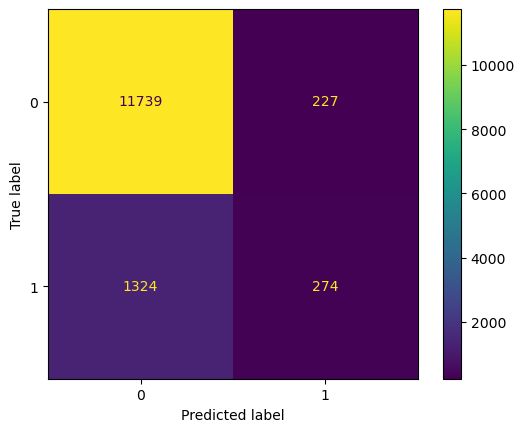

In [64]:
cfd = ConfusionMatrixDisplay(cf,display_labels=model.classes_)
cfd.plot()

In [67]:
accuracy = accuracy_score(Y_test, pred)*100
print("accuracy:", accuracy)

accuracy: 88.56531996461221


In [66]:
import joblib
joblib.dump(model,'Assignment_3_logistic_model.joblib')
print("Model Saved")

Model Saved


In [70]:
print(classification_report(Y_test,pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     11966
           1       0.55      0.17      0.26      1598

    accuracy                           0.89     13564
   macro avg       0.72      0.58      0.60     13564
weighted avg       0.86      0.89      0.86     13564

